Coherence $c_i\in\{-1,+1\}$ is equally likely and sets the correct direction (L/R). With centered pupil $p_i$, simulated drift is $v_i=c_i(\beta_1+\beta_2p_i)$; $a$, $t_0$, and $z$ are constant.

Coherence sets drift direction; pupil modulates its magnitude. The two 4p fits include coherence. The Covariate 4p Fit also includes pupil effects on all four parameters. The Variable 5p Fit uses correctness-coded responses and iid normal drift variability; its example trace illustrates independent draws, not recovered trial drifts.

The conditional accuracy function (CAF) pools trials using the coherence-defined correct boundary:

$$P(\mathrm{correct}\mid RT=t)=\frac{\sum_i f_{i,\mathrm{correct}}(t)}{\sum_i[f_{i,L}(t)+f_{i,R}(t)]},$$

where $f_{i,L}$ and $f_{i,R}$ are joint RT and response densities. Curves are computed directly from these densities, without RT binning.

In [1]:
import json
from pathlib import Path

import hssm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
from IPython.display import clear_output
from matplotlib.colors import to_rgb
from utils import conditional_accuracy, conditional_accuracy_sdv, slow_traces

from drift_diffusion.model import DriftDiffusionModel
from drift_diffusion.sim import sample_from_pdf

pytensor.config.cxx = ""

with Path("../code/config.json").open() as f:
    rc_params = json.load(f)["rc-params"]
    rc_params["font.size"] = 12
plt.rcParams.update(rc_params)

trial_dur, pupil_tau, seed, n_trials = 1.0, 20.0, 7, 1000
rng = np.random.default_rng(seed)

In [2]:
# one slow pupil trace shared across trials
pupil = 0.5 + 0.15 * slow_traces(rng, 1, n_trials, pupil_tau / trial_dur)[0]
pupil_centered = pupil - pupil.mean()
coherence = rng.choice([-1, 1], n_trials)

# positive coherence means R is correct; positive drift favors R
v_min, v_max = 0.1, 2.23 + 1.33 * np.sqrt(3)
beta_pupil = (v_max - v_min) / np.ptp(pupil)
beta_coherence = v_min + beta_pupil * (pupil.mean() - pupil.min())
v_pupil = coherence * (beta_coherence + beta_pupil * pupil_centered)
params = dict(a=0.63, t0=0.435, v=v_pupil, z=0.008)

ys = sample_from_pdf(**params, n_samples=n_trials, random_state=0)
choices, rts = np.sign(ys), np.abs(ys)

print(f"v range: {v_pupil.min():.3f} to {v_pupil.max():.3f}")
print(f"accuracy: {(choices == np.sign(coherence)).mean():.3f}")

v range: -4.533 to 4.534
accuracy: 0.889


In [3]:
X = pd.DataFrame({"coherence": coherence, "pupil_centered": pupil_centered})
param_names = ("a", "t0", "v", "z")
formulas = {name: "+1 + pupil_centered" for name in param_names}
formulas["v"] = "0 + coherence + coherence:pupil_centered"
ddm_varying = DriftDiffusionModel(**formulas).fit(X, ys)
formulas = {name: "+1" for name in param_names}
formulas["v"] = "0 + coherence"
ddm_constant = DriftDiffusionModel(**formulas).fit(X, ys)

estimate = ddm_varying.params_.reshape(len(param_names), 2)
se = np.sqrt(np.diag(ddm_varying.covariance_)).reshape(len(param_names), 2)

for i, name in enumerate(param_names):
    print(
        f"{name} pupil slope: true={beta_pupil if name == 'v' else 0:.3f}, fitted={estimate[i, 1]:.3f} +/- {se[i, 1]:.3f}"
    )
constant_v = ddm_constant.params_[2]
constant_v_se = np.sqrt(ddm_constant.covariance_[2, 2])
print(f"coherence coefficient: true={beta_coherence:.3f}, fitted={constant_v:.3f} +/- {constant_v_se:.3f}")

a pupil slope: true=0.000, fitted=-0.216 +/- 0.099
t0 pupil slope: true=0.000, fitted=0.044 +/- 0.022
v pupil slope: true=7.631, fitted=7.807 +/- 0.504
z pupil slope: true=0.000, fitted=0.041 +/- 0.110
coherence coefficient: true=2.222, fitted=1.713 +/- 0.066


In [4]:
ddm_hssm = hssm.HSSM(data=pd.DataFrame({"rt": rts, "response": choices * coherence}), model="ddm_sdv", p_outlier=1e-12)
ddm_hssm.sample()
clear_output()

In [5]:
params_hssm = {name: float(ddm_hssm.traces.posterior[name].mean()) for name in ("v", "a", "z", "t", "sv")}
trial = np.arange(1, n_trials + 1)
rt_grid = np.linspace(max(params["t0"], params_hssm["t"]) + 0.1, params["t0"] + 5, 100)
v_example = np.random.default_rng(7).normal(params_hssm["v"], params_hssm["sv"], n_trials)
accuracy_sim = conditional_accuracy(rt_grid, **params, correct_boundary=coherence)
accuracy_hssm = conditional_accuracy_sdv(rt_grid, **params_hssm)

fits = {}
for key, ddm in [("constant", ddm_constant), ("covariate", ddm_varying)]:
    bands = ddm.g(X, alpha=0.05)  # pointwise: use 0.05/n_trials for simultaneous
    accuracy = conditional_accuracy(
        rt_grid, **{name: band["g"] for name, band in bands.items()}, correct_boundary=coherence
    )
    fits[key] = (bands["v"], accuracy)


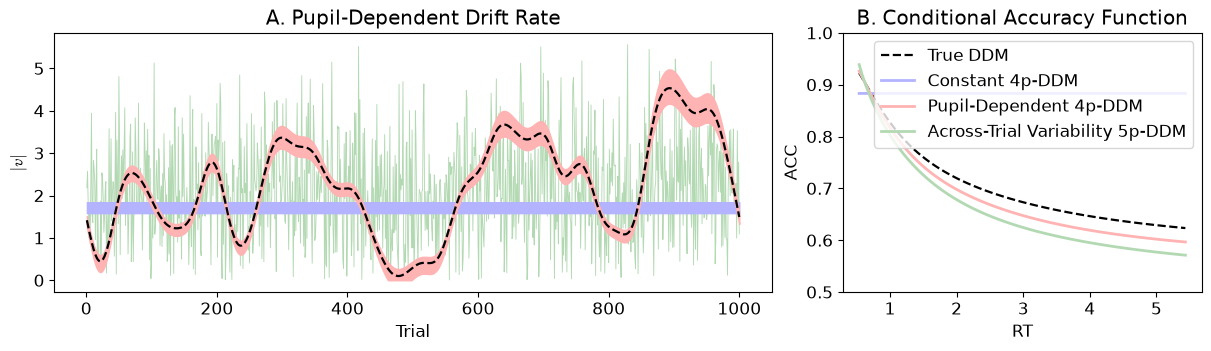

In [6]:
labels = {
    "true": "True DDM",
    "constant": "Constant 4p-DDM",
    "covariate": "Pupil-Dependent 4p-DDM",
    "variable": "Across-Trial Variability 5p-DDM",
}
axes_labels = [
    dict(xlabel="Trial", ylabel=r"$|v|$", title="A. Pupil-Dependent Drift Rate"),
    dict(xlabel="RT", ylabel="ACC", title="B. Conditional Accuracy Function"),
]
strength = 0.3
colors = {
    key: strength * np.array(to_rgb(color)) + (1 - strength)
    for key, color in [("constant", "b"), ("covariate", "r"), ("variable", "g")]
}

fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), width_ratios=[2, 1], layout="constrained")
axs[0].plot(trial, np.abs(v_example), color=colors["variable"], lw=0.65, zorder=1)
axs[0].plot(trial, np.abs(v_pupil), "--", color="k", lw=1.6, zorder=3)
axs[1].plot(rt_grid, accuracy_sim, "--", color="k", lw=1.6, label=labels["true"])
for key, (band, accuracy) in fits.items():
    lower, upper = band["-"], band["+"]
    abs_lower = np.where((lower <= 0) & (upper >= 0), 0, np.minimum(np.abs(lower), np.abs(upper)))
    axs[0].fill_between(
        trial, abs_lower, np.maximum(np.abs(lower), np.abs(upper)), color=colors[key], alpha=1, zorder=2
    )
    axs[1].plot(rt_grid, accuracy, color=colors[key], lw=2, label=labels[key])
axs[1].plot(rt_grid, accuracy_hssm, color=colors["variable"], lw=2, label=labels["variable"])
for ax, text in zip(axs, axes_labels):
    ax.set(**text)
axs[1].set_ylim(0.5, 1.0)
axs[1].legend(loc="best")

fig.savefig("../results/figXX")
